# TFLite Quantization — One Model at a Time

Each model section is **fully self-contained**: it loads its own data, converts,
evaluates, then **frees all memory** before the next section.
This prevents RAM exhaustion on 16 GB systems.

**Models:**
- Cracking (binary)
- Stringing (binary)
- Warping (binary)
- 4-Class (Cracking / Stringing / Warping / No_Defect)

> ⚠️ Run sections **one at a time** (or kernel-restart between sections if needed).

---
## 0 — Shared Imports & Helpers

Run this once at the start.

In [1]:
print(5)

5


In [2]:
import os, glob, time, gc, shutil, tempfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print(f"TF {tf.__version__}  GPU: {tf.config.list_physical_devices('GPU')}")

BASE   = os.getcwd()
DATA   = os.path.join(BASE, "data")
TFLITE = os.path.join(BASE, "tflite_models")
os.makedirs(TFLITE, exist_ok=True)

IMG_SIZE = (224, 224)
N_CALIB  = 150
N_BENCH  = 100
MAX_TEST = 350

# ── Image loading ──────────────────────────────────────────────────────────────
def load_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return (tf.cast(img, tf.float32) / 255.0).numpy()

def load_dir(folder, n=MAX_TEST):
    paths = sorted(glob.glob(os.path.join(folder, "*.jpg")))[:n]
    return np.array([load_img(p) for p in paths], dtype=np.float32)

def fmb(path): return os.path.getsize(path) / 1024**2

# ── Concrete-function trace (works with h5 models loaded in TF 2.18) ──────────
# tf.saved_model.save() and from_keras_model() both fail on h5-loaded models
# because of _DictWrapper serialization issues. Tracing via concrete functions
# bypasses serialization entirely.
def _get_concrete(model):
    @tf.function(input_signature=[tf.TensorSpec([None, 224, 224, 3], tf.float32)])
    def serve(x):
        return model(x, training=False)
    return serve.get_concrete_function()

def to_f32(model, path):
    cf = _get_concrete(model)
    c  = tf.lite.TFLiteConverter.from_concrete_functions([cf], model)
    open(path, "wb").write(c.convert())
    print(f"  float32 saved: {os.path.basename(path)}  {fmb(path):.2f} MB")

def to_f16(model, path):
    cf = _get_concrete(model)
    c  = tf.lite.TFLiteConverter.from_concrete_functions([cf], model)
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.target_spec.supported_types = [tf.float16]
    open(path, "wb").write(c.convert())
    print(f"  float16 saved: {os.path.basename(path)}  {fmb(path):.2f} MB")

def to_i8(model, path, calib):
    cf = _get_concrete(model)
    def rep():
        for img in calib: yield [img[None].astype(np.float32)]
    c  = tf.lite.TFLiteConverter.from_concrete_functions([cf], model)
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.representative_dataset = rep
    c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    c.inference_input_type = c.inference_output_type = tf.int8
    open(path, "wb").write(c.convert())
    print(f"  int8    saved: {os.path.basename(path)}  {fmb(path):.2f} MB")

# ── TFLite inference ───────────────────────────────────────────────────────────
def make_interp(path):
    it = tf.lite.Interpreter(model_path=path)
    it.allocate_tensors()
    return it

def tflite_run(it, img):
    i = it.get_input_details()[0]
    o = it.get_output_details()[0]
    it.set_tensor(i["index"], img[None].astype(i["dtype"]))
    it.invoke()
    return it.get_tensor(o["index"])

def i8_run(path, img):
    it     = make_interp(path)
    i_det  = it.get_input_details()[0]
    o_det  = it.get_output_details()[0]
    s, z   = i_det["quantization"]
    it.set_tensor(i_det["index"], (img / s + z).astype(np.int8)[None])
    it.invoke()
    raw     = it.get_tensor(o_det["index"])
    s2, z2  = o_det["quantization"]
    return (raw.astype(np.float32) - z2) * s2

# ── Metrics ────────────────────────────────────────────────────────────────────
def get_metrics(y, p, avg):
    return dict(
        accuracy  = accuracy_score(y, p),
        precision = precision_score(y, p, average=avg, zero_division=0),
        recall    = recall_score(y, p, average=avg, zero_division=0),
        f1        = f1_score(y, p, average=avg, zero_division=0),
    )

def eval_tflite(path, X, y, mode):
    it = make_interp(path); preds = []
    for img in X:
        out = tflite_run(it, img).ravel()
        preds.append(int(out[0] >= 0.5) if mode == "binary" else int(np.argmax(out)))
    avg = "binary" if mode == "binary" else "macro"
    return get_metrics(y, np.array(preds), avg)

def eval_i8(path, X, y, mode):
    preds = []
    for img in X:
        out = i8_run(path, img).ravel()
        preds.append(int(out[0] >= 0.5) if mode == "binary" else int(np.argmax(out)))
    avg = "binary" if mode == "binary" else "macro"
    return get_metrics(y, np.array(preds), avg)

def bench_tflite(path, X):
    it = make_interp(path); ts = []
    for img in X[:N_BENCH]:
        t = time.time(); tflite_run(it, img); ts.append((time.time()-t)*1e3)
    return float(np.mean(ts))

def bench_keras(model, X):
    ts = []
    for img in X[:N_BENCH]:
        t = time.time(); model.predict(img[None], verbose=0); ts.append((time.time()-t)*1e3)
    return float(np.mean(ts))

def bench_i8(path, X):
    ts = []
    for img in X[:N_BENCH]:
        t = time.time(); i8_run(path, img); ts.append((time.time()-t)*1e3)
    return float(np.mean(ts))

# ── Shared results list ────────────────────────────────────────────────────────
RESULTS = []
print("✅ Helpers ready.")


2026-05-16 10:18:36.161639: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778923116.182197   31674 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778923116.188432   31674 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-16 10:18:36.210457: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF 2.18.0  GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Helpers ready.


---
## 1 — Cracking

Binary classifier. **Label 1** = Cracking defect, **Label 0** = No Cracking.

> All data loaded here, processed, then freed before the next section.

In [3]:
print('Loading Cracking data (max 350/class)...')
cracking_imgs = load_dir(os.path.join(DATA, "Cracking"))
nocracking_imgs = load_dir(os.path.join(DATA, "No_Cracking"))

X = np.concatenate([cracking_imgs, nocracking_imgs])
y = np.array([1]*len(cracking_imgs) + [0]*len(nocracking_imgs))
calib = cracking_imgs[:N_CALIB].copy()
# Free per-class arrays, keep only X, y, calib
del cracking_imgs, nocracking_imgs
gc.collect()

for lbl,cnt in zip(*np.unique(y,return_counts=True)):
    print(f'  label {lbl}: {cnt} images')
print(f'Total: {len(X)} images  RAM: {X.nbytes/1e6:.0f} MB')


Loading Cracking data (max 350/class)...


I0000 00:00:1778923122.899131   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


  label 0: 350 images
  label 1: 350 images
Total: 700 images  RAM: 421 MB


In [4]:
print("Loading Cracking Keras model...")
model = keras.models.load_model(r"/home/feriel/PFE/Defect-Detection/cracking/mobilenetv2_cracking_finetuned_final.h5")
h5_size = fmb(r"/home/feriel/PFE/Defect-Detection/cracking/mobilenetv2_cracking_finetuned_final.h5")
print(f"  Loaded  {model.count_params():,} params  {h5_size:.2f} MB")

print("\nConverting to TFLite...")
f32_path = os.path.join(TFLITE, 'cracking_float32.tflite')
f16_path = os.path.join(TFLITE, 'cracking_float16.tflite')
i8_path  = os.path.join(TFLITE, 'cracking_int8.tflite')
to_f32(model, f32_path)
to_f16(model, f16_path)
to_i8(model,  i8_path, calib)
print("\n✅ All 3 TFLite files saved.")


Loading Cracking Keras model...


  Loaded  2,586,177 params  10.22 MB

Converting to TFLite...


I0000 00:00:1778923132.468118   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923132.468368   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923132.469112   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778923133.601750   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923133.601797   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  float32 saved: cracking_float32.tflite  9.71 MB


I0000 00:00:1778923135.758202   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923135.758391   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923135.758992   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778923136.960538   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923136.960596   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  float16 saved: cracking_float16.tflite  4.88 MB


I0000 00:00:1778923138.964018   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923138.964267   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923138.965006   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/feriel/pfe-env/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778923139.963531   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923139.963577   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  int8    saved: cracking_int8.tflite  2.91 MB

✅ All 3 TFLite files saved.


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [5]:
print("Evaluating Keras (Cracking)...")
k_time = bench_keras(model, X)
if "binary" == "binary":
    kp = (model.predict(X, batch_size=32, verbose=0).ravel() >= 0.5).astype(int)
else:
    kp = np.argmax(model.predict(X, batch_size=32, verbose=0), axis=1)
km = get_metrics(y, kp, "binary")
RESULTS.append({"model":"Cracking","format":"Keras (.h5)","size_mb":h5_size,"inf_ms":k_time,**km})
print(f"  Keras   acc={km['accuracy']:.4f}  f1={km['f1']:.4f}  {k_time:.1f} ms")

print("Evaluating float32 (Cracking)...")
t32 = bench_tflite(f32_path, X)
m32 = eval_tflite(f32_path, X, y, "binary")
RESULTS.append({"model":"Cracking","format":"TFLite float32","size_mb":fmb(f32_path),"inf_ms":t32,**m32})
print(f"  float32 acc={m32['accuracy']:.4f}  f1={m32['f1']:.4f}  {t32:.1f} ms")

print("Evaluating float16 (Cracking)...")
t16 = bench_tflite(f16_path, X)
m16 = eval_tflite(f16_path, X, y, "binary")
RESULTS.append({"model":"Cracking","format":"TFLite float16","size_mb":fmb(f16_path),"inf_ms":t16,**m16})
print(f"  float16 acc={m16['accuracy']:.4f}  f1={m16['f1']:.4f}  {t16:.1f} ms")

print("Evaluating INT8 (Cracking)...")
ti8 = bench_i8(i8_path, X)
mi8 = eval_i8(i8_path, X, y, "binary")
RESULTS.append({"model":"Cracking","format":"TFLite INT8","size_mb":fmb(i8_path),"inf_ms":ti8,**mi8})
print(f"  INT8    acc={mi8['accuracy']:.4f}  f1={mi8['f1']:.4f}  {ti8:.1f} ms")


Evaluating Keras (Cracking)...


I0000 00:00:1778923153.906108   32055 service.cc:148] XLA service 0x761124002ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778923153.906641   32055 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-16 10:19:13.947953: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778923154.392916   32055 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1778923157.097180   32055 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-05-16 10:19:24.785127: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 421478400 exceeds 10% of free system memory.
2026-05-16 10:19:25.304895: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 421478400 ex

  Keras   acc=0.9929  f1=0.9928  117.5 ms
Evaluating float32 (Cracking)...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


  float32 acc=0.9929  f1=0.9928  9.8 ms
Evaluating float16 (Cracking)...
  float16 acc=0.9929  f1=0.9928  9.5 ms
Evaluating INT8 (Cracking)...
  INT8    acc=0.9843  f1=0.9841  16.8 ms


In [6]:
# ── Free ALL memory for Cracking ───────────────────────────────────────────────
del model, X, y, calib
gc.collect()
tf.keras.backend.clear_session()
print("✅ Cracking memory freed.  RESULTS has {len(RESULTS)} rows so far.")


✅ Cracking memory freed.  RESULTS has {len(RESULTS)} rows so far.


---
## 2 — Stringing

Binary classifier. **Label 1** = Stringing defect, **Label 0** = No Stringing.

> All data loaded here, processed, then freed before the next section.

In [7]:
print('Loading Stringing data (max 350/class)...')
stringing_imgs = load_dir(os.path.join(DATA, "Stringing"))
nostringing_imgs = load_dir(os.path.join(DATA, "No_Stringing"))

X = np.concatenate([stringing_imgs, nostringing_imgs])
y = np.array([1]*len(stringing_imgs) + [0]*len(nostringing_imgs))
calib = stringing_imgs[:N_CALIB].copy()
# Free per-class arrays, keep only X, y, calib
del stringing_imgs, nostringing_imgs
gc.collect()

for lbl,cnt in zip(*np.unique(y,return_counts=True)):
    print(f'  label {lbl}: {cnt} images')
print(f'Total: {len(X)} images  RAM: {X.nbytes/1e6:.0f} MB')


Loading Stringing data (max 350/class)...
  label 0: 350 images
  label 1: 350 images
Total: 700 images  RAM: 421 MB


In [8]:
print("Loading Stringing Keras model...")
model = keras.models.load_model(r"/home/feriel/PFE/Defect-Detection/Stringing/mobilenetv2_stringing_finetuned_final.h5")
h5_size = fmb(r"/home/feriel/PFE/Defect-Detection/Stringing/mobilenetv2_stringing_finetuned_final.h5")
print(f"  Loaded  {model.count_params():,} params  {h5_size:.2f} MB")

print("\nConverting to TFLite...")
f32_path = os.path.join(TFLITE, 'stringing_float32.tflite')
f16_path = os.path.join(TFLITE, 'stringing_float16.tflite')
i8_path  = os.path.join(TFLITE, 'stringing_int8.tflite')
to_f32(model, f32_path)
to_f16(model, f16_path)
to_i8(model,  i8_path, calib)
print("\n✅ All 3 TFLite files saved.")


Loading Stringing Keras model...


  Loaded  2,586,177 params  10.22 MB

Converting to TFLite...


I0000 00:00:1778923215.437147   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923215.437448   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923215.438259   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778923216.562284   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923216.562334   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  float32 saved: stringing_float32.tflite  9.71 MB


I0000 00:00:1778923218.716643   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923218.716881   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923218.717623   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778923219.983436   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923219.983487   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  float16 saved: stringing_float16.tflite  4.89 MB


I0000 00:00:1778923222.115854   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923222.116064   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923222.116749   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/feriel/pfe-env/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778923223.147848   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923223.147900   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  int8    saved: stringing_int8.tflite  2.91 MB

✅ All 3 TFLite files saved.


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [9]:
print("Evaluating Keras (Stringing)...")
k_time = bench_keras(model, X)
if "binary" == "binary":
    kp = (model.predict(X, batch_size=32, verbose=0).ravel() >= 0.5).astype(int)
else:
    kp = np.argmax(model.predict(X, batch_size=32, verbose=0), axis=1)
km = get_metrics(y, kp, "binary")
RESULTS.append({"model":"Stringing","format":"Keras (.h5)","size_mb":h5_size,"inf_ms":k_time,**km})
print(f"  Keras   acc={km['accuracy']:.4f}  f1={km['f1']:.4f}  {k_time:.1f} ms")

print("Evaluating float32 (Stringing)...")
t32 = bench_tflite(f32_path, X)
m32 = eval_tflite(f32_path, X, y, "binary")
RESULTS.append({"model":"Stringing","format":"TFLite float32","size_mb":fmb(f32_path),"inf_ms":t32,**m32})
print(f"  float32 acc={m32['accuracy']:.4f}  f1={m32['f1']:.4f}  {t32:.1f} ms")

print("Evaluating float16 (Stringing)...")
t16 = bench_tflite(f16_path, X)
m16 = eval_tflite(f16_path, X, y, "binary")
RESULTS.append({"model":"Stringing","format":"TFLite float16","size_mb":fmb(f16_path),"inf_ms":t16,**m16})
print(f"  float16 acc={m16['accuracy']:.4f}  f1={m16['f1']:.4f}  {t16:.1f} ms")

print("Evaluating INT8 (Stringing)...")
ti8 = bench_i8(i8_path, X)
mi8 = eval_i8(i8_path, X, y, "binary")
RESULTS.append({"model":"Stringing","format":"TFLite INT8","size_mb":fmb(i8_path),"inf_ms":ti8,**mi8})
print(f"  INT8    acc={mi8['accuracy']:.4f}  f1={mi8['f1']:.4f}  {ti8:.1f} ms")


Evaluating Keras (Stringing)...


2026-05-16 10:20:43.194737: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 421478400 exceeds 10% of free system memory.
2026-05-16 10:20:43.707778: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 421478400 exceeds 10% of free system memory.


  Keras   acc=0.9929  f1=0.9928  98.2 ms
Evaluating float32 (Stringing)...
  float32 acc=0.9929  f1=0.9928  10.1 ms
Evaluating float16 (Stringing)...
  float16 acc=0.9943  f1=0.9943  9.4 ms
Evaluating INT8 (Stringing)...
  INT8    acc=0.9557  f1=0.9576  16.3 ms


In [10]:
# ── Free ALL memory for Stringing ───────────────────────────────────────────────
del model, X, y, calib
gc.collect()
tf.keras.backend.clear_session()
print("✅ Stringing memory freed.  RESULTS has {len(RESULTS)} rows so far.")


✅ Stringing memory freed.  RESULTS has {len(RESULTS)} rows so far.


---
## 3 — Warping

Binary classifier. **Label 1** = Warping defect, **Label 0** = No Warping.

> All data loaded here, processed, then freed before the next section.

In [11]:
print('Loading Warping data (max 350/class)...')
warping_imgs = load_dir(os.path.join(DATA, "Warping"))
nowarping_imgs = load_dir(os.path.join(DATA, "No_Warping"))

X = np.concatenate([warping_imgs, nowarping_imgs])
y = np.array([1]*len(warping_imgs) + [0]*len(nowarping_imgs))
calib = warping_imgs[:N_CALIB].copy()
# Free per-class arrays, keep only X, y, calib
del warping_imgs, nowarping_imgs
gc.collect()

for lbl,cnt in zip(*np.unique(y,return_counts=True)):
    print(f'  label {lbl}: {cnt} images')
print(f'Total: {len(X)} images  RAM: {X.nbytes/1e6:.0f} MB')


Loading Warping data (max 350/class)...
  label 0: 350 images
  label 1: 350 images
Total: 700 images  RAM: 421 MB


In [12]:
print("Loading Warping Keras model...")
model = keras.models.load_model(r"/home/feriel/PFE/Defect-Detection/warping/mobilenetv2_Warping_finetuned_final.h5")
h5_size = fmb(r"/home/feriel/PFE/Defect-Detection/warping/mobilenetv2_Warping_finetuned_final.h5")
print(f"  Loaded  {model.count_params():,} params  {h5_size:.2f} MB")

print("\nConverting to TFLite...")
f32_path = os.path.join(TFLITE, 'warping_float32.tflite')
f16_path = os.path.join(TFLITE, 'warping_float16.tflite')
i8_path  = os.path.join(TFLITE, 'warping_int8.tflite')
to_f32(model, f32_path)
to_f16(model, f16_path)
to_i8(model,  i8_path, calib)
print("\n✅ All 3 TFLite files saved.")


Loading Warping Keras model...


  Loaded  2,586,177 params  10.22 MB

Converting to TFLite...


I0000 00:00:1778923358.801790   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923358.802033   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923358.802663   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778923359.876956   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923359.877007   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  float32 saved: warping_float32.tflite  9.71 MB


I0000 00:00:1778923361.961684   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923361.961884   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923361.962618   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778923363.187698   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923363.187747   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  float16 saved: warping_float16.tflite  4.88 MB


I0000 00:00:1778923365.201236   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923365.201471   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923365.202076   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/feriel/pfe-env/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778923366.232385   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923366.232442   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  int8    saved: warping_int8.tflite  2.91 MB

✅ All 3 TFLite files saved.


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [13]:
print("Evaluating Keras (Warping)...")
k_time = bench_keras(model, X)
if "binary" == "binary":
    kp = (model.predict(X, batch_size=32, verbose=0).ravel() >= 0.5).astype(int)
else:
    kp = np.argmax(model.predict(X, batch_size=32, verbose=0), axis=1)
km = get_metrics(y, kp, "binary")
RESULTS.append({"model":"Warping","format":"Keras (.h5)","size_mb":h5_size,"inf_ms":k_time,**km})
print(f"  Keras   acc={km['accuracy']:.4f}  f1={km['f1']:.4f}  {k_time:.1f} ms")

print("Evaluating float32 (Warping)...")
t32 = bench_tflite(f32_path, X)
m32 = eval_tflite(f32_path, X, y, "binary")
RESULTS.append({"model":"Warping","format":"TFLite float32","size_mb":fmb(f32_path),"inf_ms":t32,**m32})
print(f"  float32 acc={m32['accuracy']:.4f}  f1={m32['f1']:.4f}  {t32:.1f} ms")

print("Evaluating float16 (Warping)...")
t16 = bench_tflite(f16_path, X)
m16 = eval_tflite(f16_path, X, y, "binary")
RESULTS.append({"model":"Warping","format":"TFLite float16","size_mb":fmb(f16_path),"inf_ms":t16,**m16})
print(f"  float16 acc={m16['accuracy']:.4f}  f1={m16['f1']:.4f}  {t16:.1f} ms")

print("Evaluating INT8 (Warping)...")
ti8 = bench_i8(i8_path, X)
mi8 = eval_i8(i8_path, X, y, "binary")
RESULTS.append({"model":"Warping","format":"TFLite INT8","size_mb":fmb(i8_path),"inf_ms":ti8,**mi8})
print(f"  INT8    acc={mi8['accuracy']:.4f}  f1={mi8['f1']:.4f}  {ti8:.1f} ms")


Evaluating Keras (Warping)...


2026-05-16 10:23:06.075944: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 421478400 exceeds 10% of free system memory.


  Keras   acc=0.9629  f1=0.9640  77.0 ms
Evaluating float32 (Warping)...
  float32 acc=0.9629  f1=0.9640  9.8 ms
Evaluating float16 (Warping)...
  float16 acc=0.9643  f1=0.9653  9.4 ms
Evaluating INT8 (Warping)...
  INT8    acc=0.9629  f1=0.9620  16.8 ms


In [14]:
# ── Free ALL memory for Warping ───────────────────────────────────────────────
del model, X, y, calib
gc.collect()
tf.keras.backend.clear_session()
print("✅ Warping memory freed.  RESULTS has {len(RESULTS)} rows so far.")


✅ Warping memory freed.  RESULTS has {len(RESULTS)} rows so far.


---
## 4 — 4-Class

4-class classifier. Labels: 0=Cracking, 1=Stringing, 2=Warping, 3=No_Defect (No_Stringing).

> All data loaded here, processed, then freed before the next section.

In [15]:
print('Loading 4-Class data (max 350/class)...')
cracking_imgs = load_dir(os.path.join(DATA, "Cracking"))
stringing_imgs = load_dir(os.path.join(DATA, "Stringing"))
warping_imgs = load_dir(os.path.join(DATA, "Warping"))
nostringing_imgs = load_dir(os.path.join(DATA, "No_Stringing"))

X = np.concatenate([cracking_imgs, stringing_imgs, warping_imgs, nostringing_imgs])
y = np.array([0]*len(cracking_imgs) + [1]*len(stringing_imgs) + [2]*len(warping_imgs) + [3]*len(nostringing_imgs))
calib = cracking_imgs[:N_CALIB].copy()
# Free per-class arrays, keep only X, y, calib
del cracking_imgs, stringing_imgs, warping_imgs, nostringing_imgs
gc.collect()

for lbl,cnt in zip(*np.unique(y,return_counts=True)):
    print(f'  label {lbl}: {cnt} images')
print(f'Total: {len(X)} images  RAM: {X.nbytes/1e6:.0f} MB')


Loading 4-Class data (max 350/class)...
  label 0: 350 images
  label 1: 350 images
  label 2: 350 images
  label 3: 350 images
Total: 1400 images  RAM: 843 MB


In [16]:
print("Loading 4-Class Keras model...")
model = keras.models.load_model(r"/home/feriel/PFE/Defect-Detection/mobilenetv2_4class_alllayers_final.h5")
h5_size = fmb(r"/home/feriel/PFE/Defect-Detection/mobilenetv2_4class_alllayers_final.h5")
print(f"  Loaded  {model.count_params():,} params  {h5_size:.2f} MB")

print("\nConverting to TFLite...")
f32_path = os.path.join(TFLITE, '4_class_float32.tflite')
f16_path = os.path.join(TFLITE, '4_class_float16.tflite')
i8_path  = os.path.join(TFLITE, '4_class_int8.tflite')
to_f32(model, f32_path)
to_f16(model, f16_path)
to_i8(model,  i8_path, calib)
print("\n✅ All 3 TFLite files saved.")


Loading 4-Class Keras model...


  Loaded  2,586,948 params  10.22 MB

Converting to TFLite...


I0000 00:00:1778923471.623088   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923471.624520   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923471.625780   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778923472.786620   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923472.786674   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  float32 saved: 4_class_float32.tflite  9.71 MB


I0000 00:00:1778923474.884709   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923474.884972   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923474.885794   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1778923474.084071   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923474.084123   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  float16 saved: 4_class_float16.tflite  4.89 MB


I0000 00:00:1778923476.288012   31674 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1778923476.288278   31674 single_machine.cc:361] Starting new session
I0000 00:00:1778923476.289001   31674 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/feriel/pfe-env/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778923477.349336   31674 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778923477.349384   31674 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


  int8    saved: 4_class_int8.tflite  2.91 MB

✅ All 3 TFLite files saved.


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [17]:
print("Evaluating Keras (4-Class)...")
k_time = bench_keras(model, X)
if "macro" == "binary":
    kp = (model.predict(X, batch_size=32, verbose=0).ravel() >= 0.5).astype(int)
else:
    kp = np.argmax(model.predict(X, batch_size=32, verbose=0), axis=1)
km = get_metrics(y, kp, "macro")
RESULTS.append({"model":"4-Class","format":"Keras (.h5)","size_mb":h5_size,"inf_ms":k_time,**km})
print(f"  Keras   acc={km['accuracy']:.4f}  f1={km['f1']:.4f}  {k_time:.1f} ms")

print("Evaluating float32 (4-Class)...")
t32 = bench_tflite(f32_path, X)
m32 = eval_tflite(f32_path, X, y, "macro")
RESULTS.append({"model":"4-Class","format":"TFLite float32","size_mb":fmb(f32_path),"inf_ms":t32,**m32})
print(f"  float32 acc={m32['accuracy']:.4f}  f1={m32['f1']:.4f}  {t32:.1f} ms")

print("Evaluating float16 (4-Class)...")
t16 = bench_tflite(f16_path, X)
m16 = eval_tflite(f16_path, X, y, "macro")
RESULTS.append({"model":"4-Class","format":"TFLite float16","size_mb":fmb(f16_path),"inf_ms":t16,**m16})
print(f"  float16 acc={m16['accuracy']:.4f}  f1={m16['f1']:.4f}  {t16:.1f} ms")

print("Evaluating INT8 (4-Class)...")
ti8 = bench_i8(i8_path, X)
mi8 = eval_i8(i8_path, X, y, "macro")
RESULTS.append({"model":"4-Class","format":"TFLite INT8","size_mb":fmb(i8_path),"inf_ms":ti8,**mi8})
print(f"  INT8    acc={mi8['accuracy']:.4f}  f1={mi8['f1']:.4f}  {ti8:.1f} ms")


Evaluating Keras (4-Class)...
  Keras   acc=1.0000  f1=1.0000  101.9 ms
Evaluating float32 (4-Class)...
  float32 acc=1.0000  f1=1.0000  9.4 ms
Evaluating float16 (4-Class)...
  float16 acc=1.0000  f1=1.0000  9.5 ms
Evaluating INT8 (4-Class)...
  INT8    acc=0.9993  f1=0.9993  -4.3 ms


In [18]:
# ── Free ALL memory for 4-Class ───────────────────────────────────────────────
del model, X, y, calib
gc.collect()
tf.keras.backend.clear_session()
print("✅ 4-Class memory freed.  RESULTS has {len(RESULTS)} rows so far.")


✅ 4-Class memory freed.  RESULTS has {len(RESULTS)} rows so far.


---
## 5 — Final Comparison Table & Plots

Run **after** all 4 model sections have completed.

In [19]:
df = pd.DataFrame(RESULTS)
df["accuracy"]  = (df["accuracy"]*100).round(2)
df["precision"] = (df["precision"]*100).round(2)
df["recall"]    = (df["recall"]*100).round(2)
df["f1"]        = (df["f1"]*100).round(2)
df["size_mb"]   = df["size_mb"].round(2)
df["inf_ms"]    = df["inf_ms"].round(2)

display(df[["model","format","size_mb","accuracy","precision","recall","f1","inf_ms"]]
          .rename(columns={"model":"Model","format":"Format","size_mb":"Size (MB)",
                           "accuracy":"Acc (%)","precision":"Prec (%)","recall":"Rec (%)",
                           "f1":"F1 (%)","inf_ms":"Inf (ms)"}))

df.to_csv("quantization_results.csv", index=False)
print("✅ quantization_results.csv saved")


,Model,Format,Size (MB),Acc (%),Prec (%),Rec (%),F1 (%),Inf (ms)
0,Cracking,Keras (.h5),10.22,99.29,99.43,99.14,99.28,117.53
1,Cracking,TFLite float32,9.71,99.29,99.43,99.14,99.28,9.77
2,Cracking,TFLite float16,4.88,99.29,99.43,99.14,99.28,9.47
3,Cracking,TFLite INT8,2.91,98.43,99.71,97.14,98.41,16.83
4,Stringing,Keras (.h5),10.22,99.29,99.43,99.14,99.28,98.20
5,Stringing,TFLite float32,9.71,99.29,99.43,99.14,99.28,10.07
6,Stringing,TFLite float16,4.89,99.43,99.43,99.43,99.43,9.41
7,Stringing,TFLite INT8,2.91,95.57,91.86,100.00,95.76,16.29
8,Warping,Keras (.h5),10.22,96.29,93.55,99.43,96.40,77.00
9,Warping,TFLite float32,9.71,96.29,93.55,99.43,96.40,9.77


✅ quantization_results.csv saved


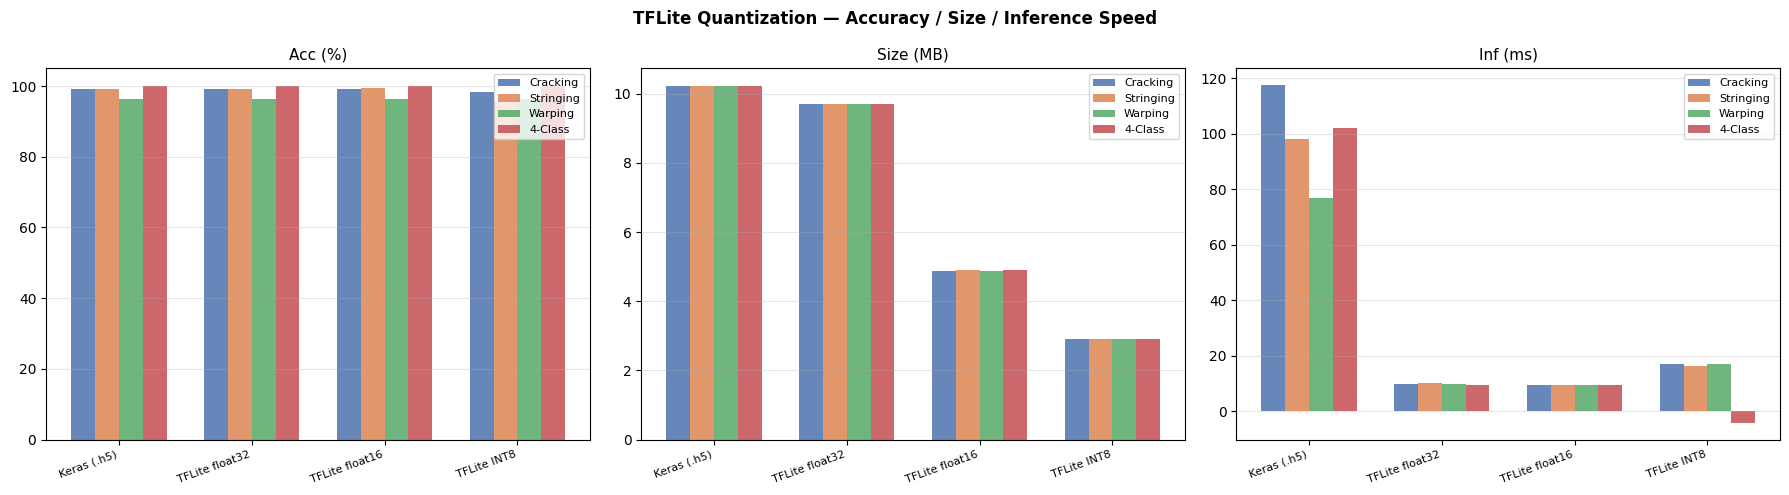

In [20]:
models_order  = ["Cracking","Stringing","Warping","4-Class"]
formats_order = ["Keras (.h5)","TFLite float32","TFLite float16","TFLite INT8"]
colors = ["#4C72B0","#DD8452","#55A868","#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, col in zip(axes, ["Acc (%)","Size (MB)","Inf (ms)"]):
    rdf = df.rename(columns={"accuracy":"Acc (%)","size_mb":"Size (MB)","inf_ms":"Inf (ms)"})
    x   = np.arange(len(formats_order)); w = 0.18
    for i, mname in enumerate(models_order):
        sub  = rdf[rdf["model"]==mname]
        vals = [sub[sub["format"]==f][col].values[0] if len(sub[sub["format"]==f]) else 0
                for f in formats_order]
        ax.bar(x + i*w, vals, w, label=mname, color=colors[i], alpha=0.85)
    ax.set_title(col, fontsize=11)
    ax.set_xticks(x + w*1.5)
    ax.set_xticklabels(formats_order, rotation=20, ha="right", fontsize=8)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.suptitle("TFLite Quantization — Accuracy / Size / Inference Speed", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
